# Ablation Study: Structured Style Vectors (Format Signature / Structural Vector / Pragmatic Style)

Based on Model V2 (styled-qwen-balanced), this notebook evaluates feature ablations under the updated training-style schema:
- Formatting Signature (lexical cues + punctuation tendencies)
- 6-D structural vector
- Pragmatic style (semantic traits)

## 1. Import Dependencies and Environment Setup

In [1]:
import json
import os
import random
import time
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import LabelEncoder
from sentence_transformers import SentenceTransformer, util
from transformers import Qwen3ForCausalLM
from peft import PeftModel

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

PROJECT_ROOT  = Path.cwd()
OTAKU_ROOT    = PROJECT_ROOT.parent
OUTPUT_ROOT   = OTAKU_ROOT / "outputs"
MODEL_BASE    = Path("/root/autodl-tmp")

SAVE_DIR         = OUTPUT_ROOT / "styled-qwen-v4.3-4e-05"
DPO_SAVE_DIR     = OUTPUT_ROOT / "styled-qwen-dpo-v1/checkpoint-150"
MODEL_LABEL      = "Modelv4.3"
BASE_MODEL_PATH  = MODEL_BASE  / "Qwen3-1.7B/"
TEST_FILE        = OTAKU_ROOT / "data" / "neutral_sentences_eval.jsonl"
RESULT_DIR       = OUTPUT_ROOT / "ablation_style_vectors"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

STRUCTURAL_DIMS = [
    "mdd",
    "verb_noun_ratio",
    "question_ratio",
    "imperative_ratio",
    "fragment_ratio",
    "marker_density",
]


/root/miniconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.8.0+cu128).


Device: cuda


## 2. Load Model and Test Set

In [ ]:
class StyleEncoder(nn.Module):
    def __init__(self, input_dim: int, out_dim: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, out_dim // 2),
            nn.ReLU(),
            nn.Linear(out_dim // 2, out_dim),
            nn.Tanh()
        )
    def forward(self, x):
        return self.proj(x)

print("Loading Model...")
tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR / "tokenizer")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = Qwen3ForCausalLM.from_pretrained(BASE_MODEL_PATH,
                                              dtype=torch.bfloat16,
                                              attn_implementation="sdpa",
                                              device_map={"": torch.cuda.current_device()} if torch.cuda.is_available() else "auto",
                                              )
model_v2 = PeftModel.from_pretrained(base_model, DPO_SAVE_DIR)
hidden_size = base_model.config.hidden_size
calc_dtype = getattr(base_model.config, "torch_dtype", None) or torch.bfloat16

style_encoder = StyleEncoder(len(STRUCTURAL_DIMS), hidden_size)  # type:ignore
style_encoder.load_state_dict(
    torch.load(SAVE_DIR / "style_encoder.pt", map_location=DEVICE)
)
style_encoder = style_encoder.to(DEVICE, dtype=calc_dtype)
style_encoder.eval()

model_v2.eval()
print("Model loaded.")

with open(TEST_FILE, "r", encoding="utf-8") as f:
    test_sentences: list[str] = [json.loads(l)["neutral"] for l in f if l.strip()]

print(f"Test set size: {len(test_sentences)}")
print("Samples:", test_sentences[:3])

Loading Model...


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Model loaded.
Test set size: 150
Samples: ['这是你特意为我准备的点心？看来你对我很了解啊。好吧，我就尝一尝。', '你们的能力尚不足。', '我不太喜欢吃甜食，但既然你是亲手做的，我就尝一下。']


In [3]:
from typing_extensions import TypedDict

# ── Build semantic tags from pragmatic vectors (same rule as training/eval) ─────
CHARACTER_TO_PRAG_FILE = {
    "沐雪": "muice.jsonl",
    "神里绫华": "ayaka.jsonl",
    "钟离": "zhongli.jsonl",
    "胡桃": "hutao.jsonl",
    "凉宫春日": "haruhi.jsonl",
    "李云龙": "liyunlong.jsonl",
    "谢尔顿": "sheldon.jsonl",
    "孙悟空": "wukong.jsonl"
}

PRAGMATIC_DIR = OUTPUT_ROOT / "style" / "semantic" / "prag_vectors"

class RawPragmaticItem(TypedDict):
    prompt: str
    response: str
    pragmatic_styles: list[dict[str, float]]


class CharacterProfile(TypedDict):
    character: str
    semantic_tags: list[str]
    structural_metrics: dict[str, float]
    signature_rules: list[str]

def compute_character_top_semantic_tags(character: str, top_k: int = 5) -> list[str]:
    """
    对齐 13 notebook 的 compute_style_statistics 统计口径：
    按标签 activation_rate（出现样本占比）排序，并用 avg_probability 作为并列打破规则。
    """
    prag_file_name = CHARACTER_TO_PRAG_FILE.get(character)
    if prag_file_name is None:
        raise ValueError(f"{character} 的角色标签不存在！")

    prag_file = PRAGMATIC_DIR / prag_file_name
    if not prag_file.exists():
        raise ValueError(f"{character} 的角色标签不存在！")

    score_sums: dict[str, float] = defaultdict(float)
    score_counts: dict[str, int] = defaultdict(int)
    activation_counts: dict[str, int] = defaultdict(int)
    total_samples = 0

    with open(prag_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            raw_item: RawPragmaticItem = json.loads(line)
            pragmatic_styles = raw_item.get("pragmatic_styles", [])
            if not pragmatic_styles:
                continue

            total_samples += 1
            activated_in_sample: set[str] = set()

            for vec in pragmatic_styles:
                for tag, score in vec.items():
                    score_sums[tag] += float(score)
                    score_counts[tag] += 1
                    activated_in_sample.add(tag)

            for tag in activated_in_sample:
                activation_counts[tag] += 1

    if not score_sums or total_samples == 0:
        return []

    tag_records = [
        (
            tag,
            activation_counts[tag] / total_samples,
            score_sums[tag] / score_counts[tag],
        )
        for tag in score_sums.keys()
        if score_counts[tag] > 0
    ]
    tag_records.sort(key=lambda x: (x[1], x[2]), reverse=True)
    return [tag for tag, _, _ in tag_records[:top_k]]

muice_profile = CharacterProfile(
    character="沐雪",
    semantic_tags=compute_character_top_semantic_tags("沐雪"),
    structural_metrics={
        "mdd": 0.2201,
        "verb_noun_ratio": 0.8084,
        "question_ratio": 0.8631,
        "imperative_ratio": 0.4648,
        "fragment_ratio": 0.7843,
        "marker_density": 0.4233,
    },
    signature_rules=[
        "Lexical cues: 喵, 沐沐, AI, ~, 沐雪, 恼, 女孩子, ⭐, 聊天, 唔, 呀, 可爱, 答, 不行, 笨蛋, 雪雪, 直播, 脸红, 睡觉, www, 谢谢, 变态, 骂, 嘛, 杂鱼",
        "Punctuation tendencies: ..., ⭐, ?!, multi-!, ♪, ❤",
    ],
)

ayaka_profile = CharacterProfile(
    character="神里绫华",
    semantic_tags=compute_character_top_semantic_tags("神里绫华"),
    structural_metrics={
        "mdd": 0.4102,
        "verb_noun_ratio": 0.0841,
        "question_ratio": 0.1381,
        "imperative_ratio": 0.1808,
        "fragment_ratio": 0.2789,
        "marker_density": 0.0668,
    },
    signature_rules=[
        "Lexical cues: 稻妻国, 神里家, 稻妻, 大小姐, 家族, 传统, 神, 奉行, 眼狩令, 当地, 美丽, 社, 舞蹈, 茶道, 神社, 文化, 剑术, 眼, 祭典, 旅行者, 美食, 继承, 历史, 神明, 派蒙",
        "Punctuation tendencies: ⋯, ...",
    ],
)

zhongli_profile = CharacterProfile(
    character="钟离",
    semantic_tags=compute_character_top_semantic_tags("钟离"),
    structural_metrics={
        "mdd": 0.3458,
        "verb_noun_ratio": 0.0006,
        "question_ratio": 0.3969,
        "imperative_ratio": 0.2680,
        "fragment_ratio": 0.7750,
        "marker_density": 0.0,
    },
    signature_rules=[
        "Lexical cues: 岩石, 岩, 璃月, 璃, 力, 契约, 炼金术, 月, 盐, 帝君, 魔神, 操控, 岩王, 王, 封印, 元素, 大陆, 七星, 客卿, 岩元素, 大地, 学问, 力量, 凝光, 易事",
        "Punctuation tendencies: ...",
    ],
)

hutao_profile = CharacterProfile(
    character="胡桃",
    semantic_tags=compute_character_top_semantic_tags("胡桃"),
    structural_metrics={
        "mdd": 1.0,
        "verb_noun_ratio": 0.3783,
        "question_ratio": 0.4059,
        "imperative_ratio": 0.3408,
        "fragment_ratio": 0.7260,
        "marker_density": 1.0,
    },
    signature_rules=[
        "Lexical cues: 往生堂, 嘿嘿, 嘻嘻, 堂主, 宝藏, 可是, 哎呀呀, 哦哦哦, 诗歌, 神秘, 惊喜, 谜题, 胡桃, 有趣, 灵魂, 哈哈哈, 秘密, 哇, 奇妙, 意想不到, 隐藏, 亡灵, 生死, 冒险, 巫师",
        "Punctuation tendencies: ..., ♪",
    ],
)

haruhi_profile = CharacterProfile(
    character="凉宫春日",
    semantic_tags=compute_character_top_semantic_tags("凉宫春日"),
    structural_metrics={
        "mdd": 0.4891,
        "verb_noun_ratio": 0.3785,
        "question_ratio": 0.7901,
        "imperative_ratio": 0.2811,
        "fragment_ratio": 1.0,
        "marker_density": 0.4223,
    },
    signature_rules=[
        "Lexical cues: SOS, 阿虚, 社团, 团, 哼, 学校, 事件, 朝比奈, 超自然, 文化祭, 吸引, 古泉, 创意, 实玖瑠, 与众不同, 创新, 电影, 束缚, 凉宫, 主题, 外星人, 学姐, 举办, 奇怪, 加入",
        "Punctuation tendencies: ..., ·",
    ],
)

liyunlong_profile = CharacterProfile(
    character="李云龙",
    semantic_tags=compute_character_top_semantic_tags("李云龙"),
    structural_metrics={
        "mdd": 0.4897,
        "verb_noun_ratio": 0.5131,
        "question_ratio": 1.0,
        "imperative_ratio": 1.0,
        "fragment_ratio": 0.9085,
        "marker_density": 0.0229,
    },
    signature_rules=[
        "Lexical cues: 鬼子, 咱们, 中国人, 敌人, 不怕, 侵略者, 军人, 保卫, 兄弟们, 李云龙, 别, 狠狠, 政委, 部队, 小子, 打仗, 独立, 祖国, 中国, 国家, 日本, 屁, 牺牲, 教训, 楚",
        "Punctuation tendencies: ?!, ...",
    ],
)

wukong_profile = CharacterProfile(
    character="孙悟空",
    semantic_tags=["energetic", "playful", "irritable", "loyal", "confident"],  # 替换分类器错误分类
    structural_metrics={
        "mdd": 0.3997,
        "verb_noun_ratio": 0.5705,
        "question_ratio": 0.7424,
        "imperative_ratio": 0.3252,
        "fragment_ratio": 0.5560,
        "marker_density": 0.1086,
    },
    signature_rules=[
        "Lexical cues: 师父, 老孙, 孙, 老, 哩, 莫, 甚么, 妖精, 怪, 儿, 等, 呆子, 甚, 不曾, 罢, 菩萨, 教, 不知, 若是, 泼, 却, 棍, 如今, 这般, 云",
    ],
)

sheldon_profile = CharacterProfile(
    character="谢尔顿",
    semantic_tags=compute_character_top_semantic_tags("谢尔顿"),
    structural_metrics={
        "mdd": 0.2660,
        "verb_noun_ratio": 0.0,
        "question_ratio": 0.5998,
        "imperative_ratio": 0.4395,
        "fragment_ratio": 0.6591,
        "marker_density": 0.4862,
    },
    signature_rules=[
        "Lexical cues: 伦纳德, 佩妮, 智力, 莱纳德, 必须, 科学, 逻辑, 令, 指出, 实验, 绝非, 已, 卓越, 霍华德, 概念, 至关重要, 类, 量子, 项, 着迷, 恪守, 毫无, 因此, 此, 理论",
    ],
)

ALL_PROFILES = [muice_profile, ayaka_profile, zhongli_profile, hutao_profile, haruhi_profile, liyunlong_profile, sheldon_profile, wukong_profile]
NAME_TO_PROFILE = {p["character"]: p for p in ALL_PROFILES}

print("Character profiles loaded:", [p["character"] for p in ALL_PROFILES])
print(f"Structural dims used: {STRUCTURAL_DIMS}")

Character profiles loaded: ['沐雪', '神里绫华', '钟离', '胡桃', '凉宫春日', '李云龙', '谢尔顿', '孙悟空']
Structural dims used: ['mdd', 'verb_noun_ratio', 'question_ratio', 'imperative_ratio', 'fragment_ratio', 'marker_density']


## 3. Define Ablation Prompt-Building and Inference Function

The function accepts four switches:
- `use_signature`
- `use_structural`
- `use_pragmatic`
- `enable_thinking` (CoT on/off)

When a switch is **False**:
- `use_signature=False`: remove **Formatting Signature** (lexical + punctuation)
- `use_structural=False`: replace the 6-D structural vector with all zeros
- `use_pragmatic=False`: remove **Semantic Traits** (personality/pragmatic style)
- `enable_thinking=False`: disable CoT thinking mode during generation

In [13]:
ZERO_STRUCTURAL_VEC = {dim: 0.0 for dim in STRUCTURAL_DIMS}


def build_prompt(
    neutral: str,
    profile: CharacterProfile,
    *,
    use_signature: bool = True,
    use_structural: bool = True,
    use_pragmatic: bool = True,
) -> tuple[str, dict[str, float]]:
    """
    Returns (formatted_user_prompt_text, effective_structural_vec).
    - use_signature=False  -> Formatting Signature field is set to "None"
    - use_pragmatic=False  -> Semantic Traits field is set to "None"
    - use_structural=False -> structural vector is zeroed (StyleEncoder gets no structural signal)
    """
    semantic_text = ", ".join(profile["semantic_tags"]) if use_pragmatic and profile["semantic_tags"] else "None"
    signature_text = " ".join(profile["signature_rules"]) if use_signature and profile["signature_rules"] else "None"
    eff_structural_vec = profile["structural_metrics"] if use_structural else ZERO_STRUCTURAL_VEC

    user_prompt = (
        f"Target Character: {profile['character']}\n"
        f"Semantic Traits: {semantic_text}\n"
        f"Formatting Signature: {signature_text}\n"
        f"Neutral Content: {neutral}\n"
    )
    return user_prompt, eff_structural_vec



@torch.inference_mode()
def generate_ablation(
    neutral: str,
    profile: CharacterProfile,
    *,
    use_signature: bool = True,
    use_structural: bool = True,
    use_pragmatic: bool = True,
    enable_thinking: bool = True,
    temperature: float = 0.5,
    top_p: float = 0.9,
    repetition_penalty: float = 1.05,
    max_new_tokens: int = 768,
) -> str:
    """Single-sample inference wrapper with ablation flags."""
    outputs = generate_ablation_batch(
        [neutral],
        profile,
        use_signature=use_signature,
        use_structural=use_structural,
        use_pragmatic=use_pragmatic,
        enable_thinking=enable_thinking,
        temperature=temperature,
        top_p=top_p,
        repetition_penalty=repetition_penalty,
        max_new_tokens=max_new_tokens,
    )
    return outputs[0] if outputs else ""


@torch.inference_mode()
def generate_ablation_batch(
    neutral_batch: list[str],
    profile: CharacterProfile,
    *,
    use_signature: bool = True,
    use_structural: bool = True,
    use_pragmatic: bool = True,
    enable_thinking: bool = True,
    temperature: float = 0.5,
    top_p: float = 0.9,
    repetition_penalty: float = 1.05,
    max_new_tokens: int = 768,
) -> list[str]:
    """Batch inference wrapper for higher GPU utilization."""
    if not neutral_batch:
        return []

    system_prompt = (
        "You are an expert in stylistic rewriting. "
        "Your task is to rewrite the neutral sentence into the target character's specific pragmatics and formatting style."
    )

    input_texts: list[str] = []
    structural_rows: list[list[float]] = []

    for neutral in neutral_batch:
        user_prompt, eff_structural_vec = build_prompt(
            neutral,
            profile,
            use_signature=use_signature,
            use_structural=use_structural,
            use_pragmatic=use_pragmatic,
        )
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
        input_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=enable_thinking,
        )

        if enable_thinking:
            # 在思考过程中，在 <think> 标签后强行注入一个中文锚点
            input_text.strip()
            input_text = input_text + " <think>思考: "

        input_texts.append(input_text)
        structural_rows.append([eff_structural_vec.get(d, 0.0) for d in STRUCTURAL_DIMS])

    # 关键修正 1：因果约束下的批量生成(Batch Generation) 强制依赖左侧填充 (Left Padding)
    original_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"

    tokenized = tokenizer(
        input_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(DEVICE)
    
    tokenizer.padding_side = original_padding_side

    input_ids = tokenized["input_ids"]
    attention_mask = tokenized["attention_mask"]

    # StyleEncoder prefix (zeroed when use_structural=False)
    style_dtype = next(style_encoder.parameters()).dtype
    structural_tensor = torch.tensor(
        structural_rows,
        dtype=style_dtype,
        device=DEVICE,
    )
    style_emb = style_encoder(structural_tensor).to(model_v2.dtype)
    style_prefix = style_emb.unsqueeze(1)

    token_embeds = model_v2.get_input_embeddings()(input_ids)  # type: ignore[operator]
    inputs_embeds = torch.cat([style_prefix, token_embeds], dim=1)

    prefix_mask = torch.ones((input_ids.shape[0], 1), dtype=torch.long, device=DEVICE)
    new_attn_mask = torch.cat([prefix_mask, attention_mask], dim=1)

    # 关键修正 2：通过 input_embeds 生成时显式提供 pad_token 以规范内部的 Attention 处理
    outputs = model_v2.generate(
        inputs_embeds=inputs_embeds,
        attention_mask=new_attn_mask,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=top_p,
        repetition_penalty=repetition_penalty,
        do_sample=True,
        pad_token_id=tokenizer.pad_token_id,
    )

    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    return decoded


print("Ablation inference function ready (single + batch).")

Ablation inference function ready (single + batch).


## 4. w/o Formatting Signature: Lexical + Punctuation Ablation

Formatting Signature field is replaced with `None`, i.e., lexical cues and punctuation tendencies are both removed.
Semantic traits and structural vector are kept.

In [5]:
# Quick sanity check: show what the ablated prompt looks like for one sample
sample_neutral = test_sentences[0]
sample_profile = muice_profile

ablated_prompt, _ = build_prompt(
    sample_neutral,
    sample_profile,
    use_signature=False,
    use_structural=True,
    use_pragmatic=True,
)
print("=== w/o Formatting Signature – ablated prompt ===")
print(ablated_prompt)

=== w/o Formatting Signature – ablated prompt ===
Target Character: 沐雪
Semantic Traits: cute, energetic, playful, kind, rational
Formatting Signature: None
Neutral Content: 这是你特意为我准备的点心？看来你对我很了解啊。好吧，我就尝一尝。



## 5. w/o Structural Vector

The 6-D structural vector $\mathbf{v}_{dense} \in \mathbb{R}^{6}$ is replaced with all-zeros, so the StyleEncoder prefix carries no structural style signal.
Formatting signature and semantic traits are kept.

In [6]:
ablated_prompt_struct, eff_vec_struct = build_prompt(
    sample_neutral,
    sample_profile,
    use_signature=True,
    use_structural=False,
    use_pragmatic=True,
)
print("=== w/o Structural Vector – effective vector (should all be 0.0) ===")
print(eff_vec_struct)
print("\nPrompt (structural signal zeroed – only affects StyleEncoder, not prompt text):")
print(ablated_prompt_struct)

=== w/o Structural Vector – effective vector (should all be 0.0) ===
{'mdd': 0.0, 'verb_noun_ratio': 0.0, 'question_ratio': 0.0, 'imperative_ratio': 0.0, 'fragment_ratio': 0.0, 'marker_density': 0.0}

Prompt (structural signal zeroed – only affects StyleEncoder, not prompt text):
Target Character: 沐雪
Semantic Traits: cute, energetic, playful, kind, rational
Formatting Signature: Lexical cues: 喵, 沐沐, AI, ~, 沐雪, 恼, 女孩子, ⭐, 聊天, 唔, 呀, 可爱, 答, 不行, 笨蛋, 雪雪, 直播, 脸红, 睡觉, www, 谢谢, 变态, 骂, 嘛, 杂鱼 Punctuation tendencies: ..., ⭐, ?!, multi-!, ♪, ❤
Neutral Content: 这是你特意为我准备的点心？看来你对我很了解啊。好吧，我就尝一尝。



## 6. w/o Pragmatic Style

Semantic Traits (personality/pragmatic style) are replaced with `None` in the prompt.
Formatting signature and structural vector are kept.

In [7]:
ablated_prompt_prag, _ = build_prompt(
    sample_neutral,
    sample_profile,
    use_signature=True,
    use_structural=True,
    use_pragmatic=False,
)
print("=== w/o Pragmatic Style – ablated prompt ===")
print(ablated_prompt_prag)

=== w/o Pragmatic Style – ablated prompt ===
Target Character: 沐雪
Semantic Traits: None
Formatting Signature: Lexical cues: 喵, 沐沐, AI, ~, 沐雪, 恼, 女孩子, ⭐, 聊天, 唔, 呀, 可爱, 答, 不行, 笨蛋, 雪雪, 直播, 脸红, 睡觉, www, 谢谢, 变态, 骂, 嘛, 杂鱼 Punctuation tendencies: ..., ⭐, ?!, multi-!, ♪, ❤
Neutral Content: 这是你特意为我准备的点心？看来你对我很了解啊。好吧，我就尝一尝。



## 6.5. w/o CoT

Disable thinking mode at inference time by setting `enable_thinking=False`.
This ablation keeps formatting signature, structural vector, and semantic traits unchanged, and only removes CoT behavior.

In [8]:
print("=== w/o CoT setting ===")
print("enable_thinking = False")
print("This ablation only affects generation thinking mode; prompt content remains unchanged.")

# Optional quick check (uncomment to run one sample generation):
# sample_output_wo_cot = generate_ablation(
#     sample_neutral,
#     sample_profile,
#     use_signature=True,
#     use_structural=True,
#     use_pragmatic=True,
#     enable_thinking=False,
# )
# print(sample_output_wo_cot)

=== w/o CoT setting ===
enable_thinking = False
This ablation only affects generation thinking mode; prompt content remains unchanged.


## 7. Batch Inference and Result Collection

Full V2 baseline is loaded directly from outputs/batch_run_result.jsonl,
and used to replace existing Full_V2 rows in outputs/ablation_style_vectors/ablation_results.jsonl.

Non-Full_V2 ablation variants are regenerated in this section each run.

Final results are saved to outputs/ablation_style_vectors/ablation_results.jsonl.

In [14]:
# ── Experiment configurations (ablations only; Full_V2 is loaded from batch_run_result) ──
ABLATION_CONFIGS = [
    {
        "name": "w/o_FormatSignature",
        "ablation_dimension": "format_signature",
        "use_signature": False,
        "use_structural": True,
        "use_pragmatic": True,
        "enable_thinking": True,
    },
    {
        "name": "w/o_StructuralVector",
        "ablation_dimension": "structural_vector",
        "use_signature": True,
        "use_structural": False,
        "use_pragmatic": True,
        "enable_thinking": True,
    },
    {
        "name": "w/o_PragmaticStyle",
        "ablation_dimension": "pragmatic_style",
        "use_signature": True,
        "use_structural": True,
        "use_pragmatic": False,
        "enable_thinking": True,
    },
    {
        "name": "w/o_CoT",
        "ablation_dimension": "cot",
        "use_signature": True,
        "use_structural": True,
        "use_pragmatic": True,
        "enable_thinking": False,
    },
]

OUTPUT_JSONL = RESULT_DIR / "ablation_results.jsonl"
FULL_V2_SOURCE_JSONL = OUTPUT_ROOT / "batch_run_result.jsonl"
BATCH_SIZE = 80


def _load_full_v2_from_batch(path: Path) -> list[dict]:
    if not path.exists():
        raise FileNotFoundError(f"Baseline file not found: {path}")

    full_rows: list[dict] = []
    with open(path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            item = json.loads(line)
            if item.get("model", "").strip() != MODEL_LABEL:
                continue

            neutral = str(item.get("neutral", "")).strip()
            output = str(item.get("output", ""))
            character = str(item.get("character", "")).strip()

            if not neutral or not character:
                print(f"[WARN] skip invalid row at line {line_no}: missing neutral/character")
                continue

            full_rows.append({
                "model": "Full_V2",
                "ablation_dimension": "none",
                "character": character,
                "neutral": neutral,
                "output": output,
                "crash": False,
                "use_signature": True,
                "use_structural": True,
                "use_pragmatic": True,
                "enable_thinking": True,
            })

    if not full_rows:
        raise ValueError(f"No Full_V2 rows parsed from baseline file: {path}")

    return full_rows


def _generate_ablation_rows(configs: list[dict]) -> list[dict]:
    generated_rows: list[dict] = []
    for cfg in configs:
        model_name = cfg["name"]
        print(f"\n{'='*60}")
        print(
            f"Running: {model_name}  "
            f"(sig={cfg['use_signature']}, struct={cfg['use_structural']}, prag={cfg['use_pragmatic']}, cot={cfg['enable_thinking']})"
        )
        print(f"Batch size: {BATCH_SIZE}")
        print(f"{'='*60}")

        for profile in ALL_PROFILES:
            for start in tqdm(range(0, len(test_sentences), BATCH_SIZE), desc=f"  {profile['character']}"):
                neutral_batch = test_sentences[start:start + BATCH_SIZE]

                try:
                    output_batch = generate_ablation_batch(
                        neutral_batch,
                        profile,
                        use_signature=cfg["use_signature"],
                        use_structural=cfg["use_structural"],
                        use_pragmatic=cfg["use_pragmatic"],
                        enable_thinking=cfg["enable_thinking"],
                    )
                    if len(output_batch) != len(neutral_batch):
                        raise RuntimeError("Batch output size mismatch")

                    for neutral, output in zip(neutral_batch, output_batch):
                        generated_rows.append({
                            "model": model_name,
                            "ablation_dimension": cfg["ablation_dimension"],
                            "character": profile["character"],
                            "neutral": neutral,
                            "output": output,
                            "crash": False,
                            "use_signature": cfg["use_signature"],
                            "use_structural": cfg["use_structural"],
                            "use_pragmatic": cfg["use_pragmatic"],
                            "enable_thinking": cfg["enable_thinking"],
                        })
                except Exception as e:
                    # 回退到单条生成，避免整批丢失
                    print(f"  [BATCH-ERROR] {model_name} / {profile['character']}: {e}")
                    for neutral in neutral_batch:
                        try:
                            output = generate_ablation(
                                neutral,
                                profile,
                                use_signature=cfg["use_signature"],
                                use_structural=cfg["use_structural"],
                                use_pragmatic=cfg["use_pragmatic"],
                                enable_thinking=cfg["enable_thinking"],
                            )
                            crash = False
                        except Exception as e_single:
                            print(f"    [SINGLE-ERROR] {model_name} / {profile['character']}: {e_single}")
                            raise

                        generated_rows.append({
                            "model": model_name,
                            "ablation_dimension": cfg["ablation_dimension"],
                            "character": profile["character"],
                            "neutral": neutral,
                            "output": output,
                            "crash": crash,
                            "use_signature": cfg["use_signature"],
                            "use_structural": cfg["use_structural"],
                            "use_pragmatic": cfg["use_pragmatic"],
                            "enable_thinking": cfg["enable_thinking"],
                        })

    return generated_rows


# ── Build final result rows ───────────────────────────────────────────────────────
full_v2_rows = _load_full_v2_from_batch(FULL_V2_SOURCE_JSONL)
print(f"Loaded Full_V2 rows from baseline file: {len(full_v2_rows)}")

print("Regenerating all non-Full_V2 ablation rows.")
ablation_rows = _generate_ablation_rows(ABLATION_CONFIGS)
print(f"Generated non-Full_V2 rows: {len(ablation_rows)}")

all_results = full_v2_rows + ablation_rows

# ── Persist to disk  ───────────────────────────
with open(OUTPUT_JSONL, "a", encoding="utf-8") as f:
    for row in all_results:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

df_all = pd.DataFrame(all_results)
print(f"\nTotal records: {len(df_all)}")
print(df_all.groupby(["model", "character"]).size().unstack())
print("\nAblation dimensions:")
print(df_all.groupby(["model", "ablation_dimension"]).size())
print(f"\nSaved to: {OUTPUT_JSONL}")

Loaded Full_V2 rows from baseline file: 1200
Regenerating all non-Full_V2 ablation rows.

Running: w/o_FormatSignature  (sig=False, struct=True, prag=True, cot=True)
Batch size: 80


  沐雪:   0%|          | 0/2 [00:00<?, ?it/s]

  神里绫华:   0%|          | 0/2 [00:00<?, ?it/s]

  钟离:   0%|          | 0/2 [00:00<?, ?it/s]

  胡桃:   0%|          | 0/2 [00:00<?, ?it/s]

...

  凉宫春日:   0%|          | 0/2 [00:00<?, ?it/s]

  李云龙:   0%|          | 0/2 [00:00<?, ?it/s]

  谢尔顿:   0%|          | 0/2 [00:00<?, ?it/s]

  孙悟空:   0%|          | 0/2 [00:00<?, ?it/s]

Generated non-Full_V2 rows: 4800

Total records: 6000
character             凉宫春日  孙悟空  李云龙   沐雪  神里绫华   胡桃  谢尔顿   钟离
model                                                         
Full_V2                150  150  150  150   150  150  150  150
w/o_CoT                150  150  150  150   150  150  150  150
w/o_FormatSignature    150  150  150  150   150  150  150  150
w/o_PragmaticStyle     150  150  150  150   150  150  150  150
w/o_StructuralVector   150  150  150  150   150  150  150  150

Ablation dimensions:
model                 ablation_dimension
Full_V2               none                  1200
w/o_CoT               cot                   1200
w/o_FormatSignature   format_signature      1200
w/o_PragmaticStyle    pragmatic_style       1200
w/o_StructuralVector  structural_vector     1200
dtype: int64

Saved to: /root/OtakuLab/outputs/ablation_style_vectors/ablation_results.jsonl


## 8. Model Robustness Validation (Crash Detection)

Before robustness checks, this section first removes CoT think traces from loaded outputs for analysis use.
Raw outputs are retained in `output_raw` for auditing, while downstream sections reuse the cleaned `output`.

For each ablation variant check:
1. **Empty output** – model returned an empty string  
2. **Repetitive degeneration** – unique-token ratio < 0.3 (a common sign of looping)  
3. **Length anomaly** – output length < 3 characters or > 5× the median length

Report crash rate per model to verify the model remains stable under feature deprivation.

In [15]:
import re

# ── (Re-)load results if running this cell independently ─────────────────────────
if "df_all" not in dir():
    df_all = pd.read_json(OUTPUT_JSONL, lines=True)


def remove_think_tags(text: str) -> str:
    if not text:
        return ""
    cleaned = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)
    if "</think>" in cleaned:
        cleaned = cleaned.split("</think>", 1)[-1]
    return cleaned.strip()


df_all = df_all.copy()
if "output_raw" not in df_all.columns:
    df_all["output_raw"] = df_all["output"].fillna("").astype(str)
else:
    df_all["output_raw"] = df_all["output_raw"].fillna("").astype(str)

# Analysis uses cleaned output; raw CoT output is retained in output_raw for audit.
df_all["output"] = df_all["output_raw"].apply(remove_think_tags)
cleaned_rows = int((df_all["output"] != df_all["output_raw"]).sum())
print(f"Removed think tags for analysis in {cleaned_rows} rows.")

# ── Median output length per group (used for length-anomaly threshold) ────────────
median_len = df_all["output"].str.len().median()


def is_degenerate(text: str, median_len: float) -> dict[str, bool]:
    if not text:
        return {"empty": True, "repetitive": False, "length_anomaly": False}
    chars = list(text)
    unique_ratio = len(set(chars)) / max(len(chars), 1)
    return {
        "empty": len(text.strip()) == 0,
        "repetitive": unique_ratio < 0.30 and len(text) > 20,
        "length_anomaly": len(text) < 3 or len(text) > 10 * median_len,
    }


crash_records = []
for _, row in df_all.iterrows():
    flags = is_degenerate(row["output"], median_len)
    any_crash = bool(row["crash"]) or any(flags.values())
    crash_records.append({
        "model": row["model"],
        "character": row["character"],
        "exception": row["crash"],
        **flags,
        "any_crash": any_crash,
    })

df_crash = pd.DataFrame(crash_records)

# Crash rate per model
crash_summary = (
    df_crash.groupby("model")[["empty", "repetitive", "length_anomaly", "exception", "any_crash"]]
    .mean()
    .mul(100)
    .round(2)
    .rename(columns=lambda c: c + " (%)")
)
crash_summary["n"] = df_crash.groupby("model")["any_crash"].count()

print("=== Crash Rate per Ablation Model ===")
display(crash_summary)

# Save
crash_summary.to_csv(RESULT_DIR / "crash_summary.csv")
df_crash_fails = df_crash[df_crash["any_crash"]]
if len(df_crash_fails):
    print(f"\n⚠️  {len(df_crash_fails)} degenerate outputs found:")
    display(df_all[df_crash["any_crash"]][["model", "character", "neutral", "output_raw", "output"]].head(10))
else:
    print("\n✅ No degenerate outputs detected – model is stable across all ablation conditions.")

Removed think tags for analysis in 4793 rows.
=== Crash Rate per Ablation Model ===


,empty (%),repetitive (%),length_anomaly (%),exception (%),any_crash (%),n
model,,,,,,
Full_V2,0.0,0.00,0.00,0.0,0.00,1200
w/o_CoT,0.0,0.17,0.17,0.0,0.17,1200
w/o_FormatSignature,0.0,0.08,0.08,0.0,0.08,1200
w/o_PragmaticStyle,0.0,0.33,0.33,0.0,0.33,1200
w/o_StructuralVector,0.0,0.42,0.42,0.0,0.42,1200



⚠️  12 degenerate outputs found:


,model,character,neutral,output_raw,output
2295,w/o_FormatSignature,孙悟空,只要和你在一起，什么都是好看的,以自信戏谑语义定调，高碎片率与动词比造就短促跳跃节奏，借“好个”“怎生”等古白话词汇及感叹号...,只说和你一处，好个好个好个好个好个好个好个好个好个好个好个好个好个好个好个好个好个好个好个好...
2514,w/o_StructuralVector,沐雪,选择道路并非取决于我一个人，而是需要我们共同商议。我们应该考虑各种因素，权衡利弊，做出最明智...,作为可爱又热情的少女，她会用高碎片率和感叹号制造活泼节奏，将“商量”转化为“商量商量”，并借...,选择道路不是我一个人的选择，而是我们要商量商量商量商量商量商量商量商量商量商量商量商量商量商...
3520,w/o_StructuralVector,孙悟空,你好，亲爱的朋友，很高兴认识你,以豪爽语义定下“好”基调，高碎片率与动词比造就短促节奏，嵌入“老孙”“儿”等 signatu...,好！好！好！好！好！好！好！好！好！好！好！好！好！好！好！好！好！好！好！好！好！好！好！...
3563,w/o_StructuralVector,孙悟空,面对强大的敌人，我们需要谨慎而有计划地行动。首先，我们要了解敌人的弱点和战斗方式，找到可以利...,作为悟空，语义上会用“老孙”等自称和口语化词汇；高动词比与碎片率使句式短促有力，节奏紧凑；再...,老儿！莫不是你那老孙们要见了强敌，不谨慎而有计划地走？先要晓得敌人的弱点，晓得他的本领，晓得...
3574,w/o_StructuralVector,孙悟空,我期望这个世界能够永远保持和平与繁荣，人民能够安居乐业，不受战乱之苦。我希望能够为人民带来希...,语义“忠诚、自信”与高疑问/祈使比驱动反问与感叹；高碎片率将长句拆解为短促节奏，配合“儿”等...,我儿！我儿！你这话说得可倒好！我儿！我儿！你这般说来，我儿！我儿！我儿！我儿！我儿！我儿！我...
3581,w/o_StructuralVector,孙悟空,宝藏？哈哈，你以为我会告诉你吗？那可是需要经历无数的考验和挑战才能得到的。但如果你有足够的勇...,作为悟空，语义上应体现自信与顽皮；高碎片率与动词比让句式松散跳跃，多用感叹、反问和口语化连接...,宝贝！宝贝！你倒是个宝贝！你倒是个宝贝！我告诉你我告诉你我告诉你我告诉你我告诉你我告诉你我告...
4378,w/o_PragmaticStyle,李云龙,不要小看我！我会证明自己的实力,作为李云龙，语义上会用“小子”等粗犷称呼，高碎片率与零标记密度造就短句爆发力，最后用“屁”及...,别小看我，你看看我这小子，我就是个老小子了，我就是个老小子，我就是个老小子，我就是个老小子，...
4741,w/o_PragmaticStyle,孙悟空,休息？这种时候不应该休息，我们是来解决问题的，不是来休息的。继续前进吧，不要浪费时间。,以“老孙”自称，高疑问与祈使比强化急切节奏；借“休”“莫”等古白话词汇及省略号、顿号，还原其...,休！休！休！休了这等闲话休了这等闲话休了这等闲话休了这等闲话休了这等闲话休了这等闲话休了这等...
4762,w/o_PragmaticStyle,孙悟空,面对强大的敌人，我们需要团结一心，发挥各自的优势，共同制定战略。我们要善用智慧和力量，不断提...,作为悟空，我将用“老孙”自称，并融入“等”、“这般”等古白话词汇，以高碎片率和祈使感强化口语...,等你等那大敌来时，老孙等你等他来，老孙等你等他来。你等我等你等你等你等你等你等你等你等你等你...
4769,w/o_PragmaticStyle,孙悟空,实力的提升需要不断的修炼和挑战。首先，要坚持日常的训练，不断提升自己的基本功和技能。其次，要...,作为悟空，他用“老孙”自称，将抽象概念转化为具体行动；高动词比与碎片率使句式短促有力，节奏紧...,实则须要不断修炼，不断锻炼。先要练得好身手，好本事，好本领，好手段。然后要多打一打，多杀一杀...


## 9. Automated Evaluation Metrics

Compute three metrics matching the primary evaluation protocol (`33_eval_automated.ipynb`):

| Metric | Description |
|--------|-------------|
| **Semantic Score** | BGE cosine similarity between neutral input and stylized output |
| **Style Score** | Cosine similarity between output embedding and the character-specific role center |
| **H-Score** | Harmonic mean of Semantic × Style (balanced trade-off) |

The composite style score can also be expressed as:
$$S = \alpha \cdot S_{lex} + \beta \cdot S_{syn} + \gamma \cdot S_{prag}, \quad \alpha + \beta + \gamma = 1$$

In [16]:
# ── Load Style Classifier (reuse from 33_eval_automated) ────────────────────────
import os
from sklearn.preprocessing import LabelEncoder
from transformers import PreTrainedTokenizerBase

CLASSIFIER_PATH = str(OUTPUT_ROOT / "evaluate" / "style-classifier")
BGE_PATH        = str(MODEL_BASE / "bge-large-zh-v1.5")


class CharacterStyleClassifier(nn.Module):
    def __init__(self, backbone_name: str, embed_dim: int = 768, proj_dim: int = 256,
                 num_roles: int = 6, dropout: float = 0.4):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(backbone_name, output_hidden_states=False)
        self.hidden_size: int = self.backbone.config.hidden_size
        self.proj = nn.Sequential(
            nn.Linear(self.hidden_size, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.classifier = nn.Linear(proj_dim, num_roles)

    def mean_pooling(self, last_hidden: torch.Tensor, attn_mask: torch.Tensor) -> torch.Tensor:
        mask_exp = attn_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        return torch.sum(last_hidden * mask_exp, 1) / torch.clamp(mask_exp.sum(1), min=1e-9)

    def forward(self, input_ids: torch.Tensor,
                attention_mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        out  = self.backbone(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        emb  = self.mean_pooling(out.last_hidden_state, attention_mask)
        proj = self.proj(emb)
        return self.classifier(proj), proj


def load_style_classifier(
    path: str,
    device: str | torch.device = "cpu",
) -> tuple[CharacterStyleClassifier, PreTrainedTokenizerBase, LabelEncoder, dict]:
    tkn: PreTrainedTokenizerBase = AutoTokenizer.from_pretrained(path)
    with open(os.path.join(path, "label_encoder.json"), encoding="utf-8") as f:
        le_json = json.load(f)
    le = LabelEncoder()
    le.classes_ = np.array(le_json["classes"])
    backbone_dim: int = AutoModel.from_pretrained(path).config.hidden_size
    clf = CharacterStyleClassifier(path, embed_dim=backbone_dim, proj_dim=256,
                                   num_roles=int(len(le.classes_)))
    chk = torch.load(os.path.join(path, "head.pt"), map_location=device)
    clf.proj.load_state_dict(chk["proj_state"])
    clf.classifier.load_state_dict(chk["classifier_state"])
    centers_npz = np.load(os.path.join(path, "role_centers.npz"))
    role_centers: dict = {k: centers_npz[k] for k in centers_npz.files}
    return clf.to(device), tkn, le, role_centers


@torch.no_grad()
def get_style_score(
    clf: CharacterStyleClassifier,
    tkn: PreTrainedTokenizerBase,
    text: str,
    center: np.ndarray,
    device: str | torch.device = "cpu",
    max_len: int = 128,
) -> float:
    clf.eval()
    enc = tkn(text, truncation=True, max_length=max_len, padding="max_length", return_tensors="pt")
    _, emb = clf.forward(enc["input_ids"].to(device), enc["attention_mask"].to(device))  # type:ignore
    e: np.ndarray = emb.cpu().numpy()[0]
    return float(np.dot(e, center) / (np.linalg.norm(e) * np.linalg.norm(center) + 1e-9))


torch.cuda.empty_cache()

print("Loading Style Classifier ...")
clf, clf_tkn, label_enc, role_centers = load_style_classifier(CLASSIFIER_PATH, DEVICE)

print("Loading BGE Semantic Model ...")
sem_model = SentenceTransformer(BGE_PATH, device=str(DEVICE))

print("✅ Evaluation models ready.")


Loading Style Classifier ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading BGE Semantic Model ...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /root/autodl-tmp/bge-large-zh-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Evaluation models ready.


In [17]:
SEM_THRESHOLD = 0.75   # semantic gate for valid_style_score

if "output_raw" not in df_all.columns:
    raise RuntimeError("Please run Section 8 first so think-tag removal is applied before evaluation.")

eval_records = []

for _, row in tqdm(df_all.iterrows(), total=len(df_all), desc="Evaluating"):
    output = str(row["output"]).strip() if row["output"] is not None else ""
    neutral = row["neutral"]
    char = row["character"]

    # skip crashed outputs
    if not output:
        eval_records.append({**row, "sem": 0.0, "style": 0.0, "h_score": 0.0, "valid_style": 0.0})
        continue

    # ── Semantic score ──────────────────────────────────────────────────────────
    embs = sem_model.encode([neutral, output], normalize_embeddings=True, show_progress_bar=False)
    sem = float(util.cos_sim(embs[0], embs[1]).item())

    # ── Style score ─────────────────────────────────────────────────────────────
    if char in role_centers:
        style = get_style_score(clf, clf_tkn, output, role_centers[char], device=DEVICE)
    else:
        style = 0.0

    # ── Derived metrics ─────────────────────────────────────────────────────────
    h_score = 2 * style * sem / (style + sem + 1e-9)
    valid_style = style if sem > SEM_THRESHOLD else style * 0.1

    eval_records.append({
        **row,
        "output": output,
        "sem": sem,
        "style": style,
        "h_score": h_score,
        "valid_style": valid_style,
    })

df_eval = pd.DataFrame(eval_records)

# ── Aggregate ────────────────────────────────────────────────────────────────────
agg = (
    df_eval.groupby("model")[["sem", "style", "h_score", "valid_style"]]
    .mean()
    .round(4)
    .rename(columns={"sem": "Semantic", "style": "Style", "h_score": "H-Score", "valid_style": "Valid Style"})
)
# sort by H-Score descending so Full_V2 is at top if it's the best
# agg = agg.sort_values("H-Score", ascending=False)

print("=== Ablation Study – Metric Summary ===")
display(agg)

# Save
df_eval.to_csv(RESULT_DIR / "eval_detailed.csv", index=False, encoding="utf-8-sig")
agg.to_csv(RESULT_DIR / "eval_summary.csv")
print(f"\nSaved detailed: {RESULT_DIR / 'eval_detailed.csv'}")
print(f"Saved summary : {RESULT_DIR / 'eval_summary.csv'}")

Evaluating:   0%|          | 0/6000 [00:00<?, ?it/s]

=== Ablation Study – Metric Summary ===


,Semantic,Style,H-Score,Valid Style
model,,,,
Full_V2,0.8966,0.6556,0.7189,0.6096
w/o_CoT,0.8937,0.6396,0.7065,0.5768
w/o_FormatSignature,0.9047,0.5970,0.6824,0.5625
w/o_PragmaticStyle,0.8851,0.6914,0.7359,0.6068
w/o_StructuralVector,0.8792,0.7031,0.7409,0.6094



Saved detailed: /root/OtakuLab/outputs/ablation_style_vectors/eval_detailed.csv
Saved summary : /root/OtakuLab/outputs/ablation_style_vectors/eval_summary.csv


## 10. Ablation Results: Visualization and Summary

Compare Full V2 vs. four ablation variants using a grouped bar chart and a per-character breakdown table.

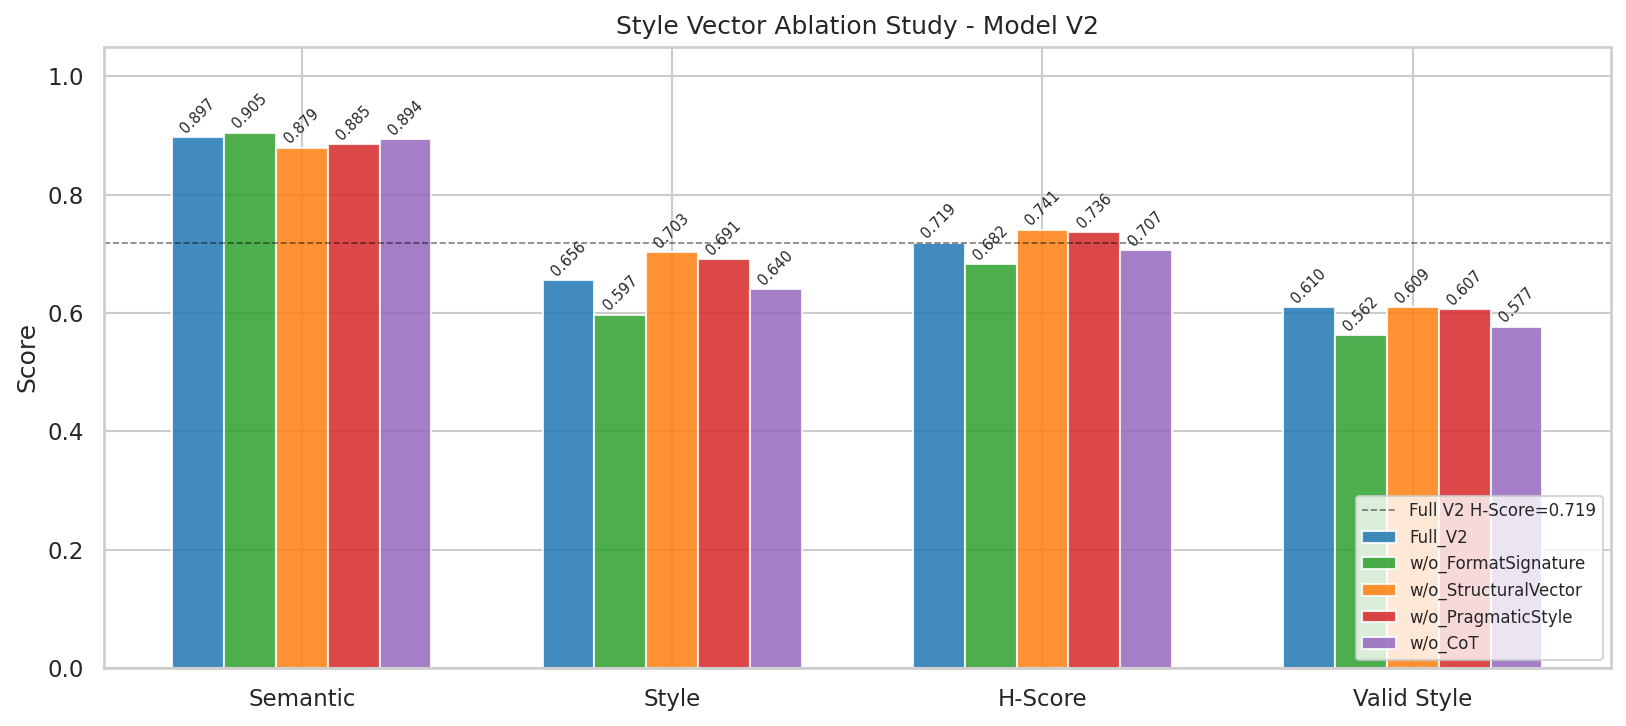

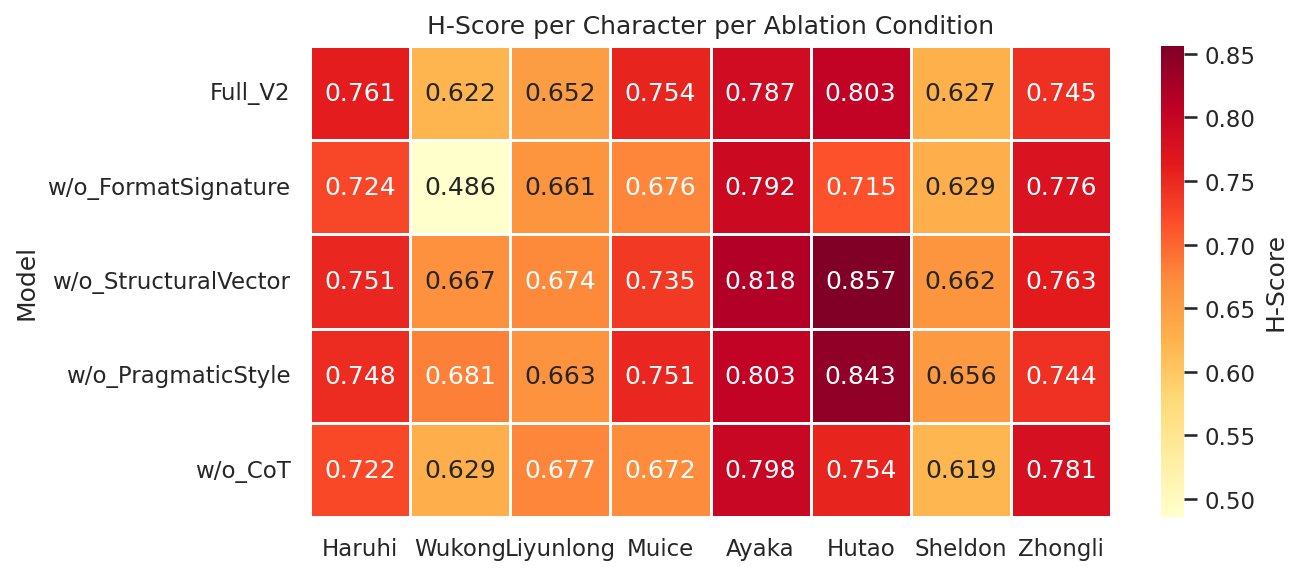


=== Final Summary Table ===


,Semantic,Style,H-Score,Valid Style
model,,,,
Full_V2,0.8966,0.6556,0.7189,0.6096
w/o_CoT,0.8937,0.6396,0.7065,0.5768
w/o_FormatSignature,0.9047,0.5970,0.6824,0.5625
w/o_PragmaticStyle,0.8851,0.6914,0.7359,0.6068
w/o_StructuralVector,0.8792,0.7031,0.7409,0.6094



All figures saved to: /root/OtakuLab/outputs/ablation_style_vectors


In [18]:
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# ── Chinese → English display name mapping (avoids CJK glyph warnings) ───────────
CHAR_EN = {
    "沐雪":    "Muice",
    "神里绫华": "Ayaka",
    "钟离":    "Zhongli",
    "胡桃":    "Hutao",
    "凉宫春日": "Haruhi",
    "李云龙":  "Liyunlong",
    "谢尔顿":  "Sheldon",
    "孙悟空":  "Wukong",
}

# ── Reload if needed ─────────────────────────────────────────────────────────────
if "agg" not in dir():
    agg = pd.read_csv(RESULT_DIR / "eval_summary.csv", index_col=0)
    df_eval = pd.read_csv(RESULT_DIR / "eval_detailed.csv")

# ── Figure 1: Grouped bar chart across models ────────────────────────────────────
METRICS     = ["Semantic", "Style", "H-Score", "Valid Style"]
MODEL_ORDER = ["Full_V2", "w/o_FormatSignature", "w/o_StructuralVector", "w/o_PragmaticStyle", "w/o_CoT"]
COLORS      = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728", "#9467bd"]

plot_df = agg.reindex(MODEL_ORDER)   # index = model name, columns = metric names

fig, ax = plt.subplots(figsize=(11, 5), dpi=150)
x = np.arange(len(METRICS))
bar_count = len(MODEL_ORDER)
width = 0.14

for i, (model_name, color) in enumerate(zip(MODEL_ORDER, COLORS)):
    if model_name not in plot_df.index:
        continue
    vals: list[float] = plot_df.loc[model_name][METRICS].to_numpy(dtype=float).tolist()  # type:ignore
    offset = (i - (bar_count - 1) / 2.0) * width
    bars = ax.bar(x + offset, vals, width, label=model_name, color=color, alpha=0.85)
    for b in bars:
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 0.002,
            f"{b.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=45,
        )

if "Full_V2" in agg.index:
    full_h = float(agg.loc[["Full_V2"], "H-Score"].to_numpy(dtype=float)[0])
    ax.axhline(
        full_h,
        linestyle="--",
        color="black",
        linewidth=0.8,
        alpha=0.5,
        label=f"Full V2 H-Score={full_h:.3f}",
    )

ax.set_xticks(x)
ax.set_xticklabels(METRICS)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Style Vector Ablation Study - Model V2")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(RESULT_DIR / "ablation_bar.pdf", bbox_inches="tight")
plt.savefig(RESULT_DIR / "ablation_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Figure 2: Per-character H-Score heatmap ──────────────────────────────────────
pivot = (
    df_eval.groupby(["model", "character"])["h_score"]
    .mean()
    .unstack("character")
    .reindex(MODEL_ORDER)
)
# Rename columns to English so no CJK font is needed
pivot.columns = [CHAR_EN.get(str(c), str(c)) for c in pivot.columns]

fig2, ax2 = plt.subplots(figsize=(9, 4), dpi=150)
sns.heatmap(
    pivot, ax=ax2, annot=True, fmt=".3f", cmap="YlOrRd",
    linewidths=0.5, cbar_kws={"label": "H-Score"},
)
ax2.set_title("H-Score per Character per Ablation Condition")
ax2.set_xlabel("")
ax2.set_ylabel("Model")
plt.tight_layout()
plt.savefig(RESULT_DIR / "ablation_heatmap.pdf", bbox_inches="tight")
plt.savefig(RESULT_DIR / "ablation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n=== Final Summary Table ===")
display(agg)

print(f"\nAll figures saved to: {RESULT_DIR}")